# A1 Coursework

## Question 1: Likelihood based analysis of the 21-cm power spectrum

### (a) PCA

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

# Load the data
data_path = "data/"
observations_data = np.load(data_path + "/observations.npz")
observations_power = observations_data["power"]
observations_ks = observations_data["k"]

ks = []
spectra = []
params = []
redshift = []
code = []
code_version = []

for file in os.listdir(data_path + "/simulations/simulations/"):
    filename = os.fsdecode(file)
    if filename.endswith(".npz"): 
        sample = np.load(data_path + "/simulations/simulations/" + filename, allow_pickle=True)
        ks.append(sample[sample.files[0]])
        spectra.append(sample[sample.files[1]])
        params.append(sample[sample.files[2]])
        redshift.append(sample[sample.files[4]])
        code.append(sample[sample.files[5]])
        code_version.append(sample[sample.files[6]])
        continue
    else:
        continue

In [ ]:
print(observations_ks)
print(sample.files)

[0.00166234 0.00187171 0.00210745 0.00237288 0.00267174 0.00300824
 0.00338713 0.00381373 0.00429407 0.0048349  0.00544385 0.00612949
 0.0069015  0.00777073 0.00874945 0.00985143 0.0110922  0.01248925
 0.01406226 0.01583338 0.01782758 0.02007294 0.0226011  0.02544768
 0.02865278 0.03226156 0.03632487 0.04089994 0.04605123 0.05185133
 0.05838194 0.06573507 0.07401432 0.08333633 0.09383244 0.10565052
 0.11895707 0.13393956 0.15080909 0.1698033  0.19118982 0.21526993
 0.24238291 0.27291074 0.30728351 0.34598548 0.38956192 0.43862676
 0.49387125 0.55607372 0.62611051 0.70496834 0.79375823 0.89373108]
['k', 'power', 'astro_params', 'cosmo_params', 'redshfit', 'code', 'code_version']


AttributeError: 'list' object has no attribute 'shape'

[0.00166234 0.00187171 0.00210745 0.00237288 0.00267174 0.00300824
 0.00338713 0.00381373 0.00429407 0.0048349  0.00544385 0.00612949
 0.0069015  0.00777073 0.00874945 0.00985143 0.0110922  0.01248925
 0.01406226 0.01583338 0.01782758 0.02007294 0.0226011  0.02544768
 0.02865278 0.03226156 0.03632487 0.04089994 0.04605123 0.05185133
 0.05838194 0.06573507 0.07401432 0.08333633 0.09383244 0.10565052
 0.11895707 0.13393956 0.15080909 0.1698033  0.19118982 0.21526993
 0.24238291 0.27291074 0.30728351 0.34598548 0.38956192 0.43862676
 0.49387125 0.55607372 0.62611051 0.70496834 0.79375823 0.89373108]


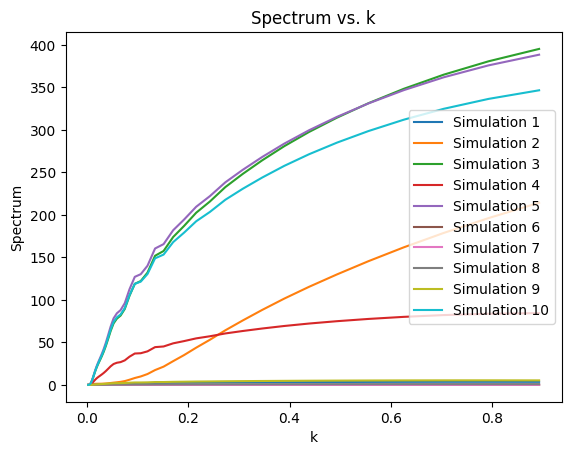

In [56]:
print(ks[0])

for i in range(10):
    plt.plot(ks[i], spectra[i], label=f"Simulation {i+1}")

#plt.plot(labels, observations, label="Observations", linestyle='dashed')
plt.xlabel("k")
plt.ylabel("Spectrum")
plt.title("Spectrum vs. k")
plt.legend()
plt.show()

/tmp/ipykernel_5238/3834178822.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(pca.components_[0], pca.components_[1], cmap='viridis')


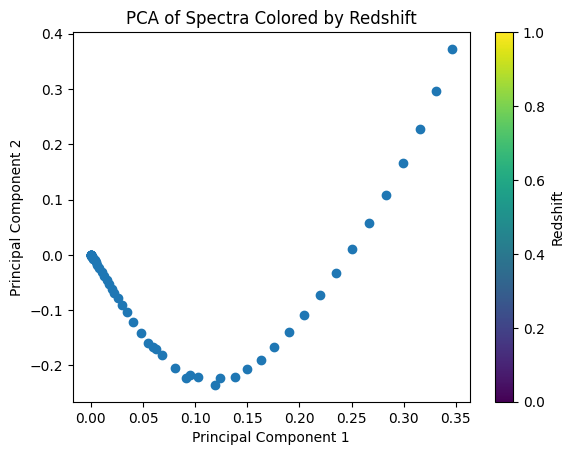

In [64]:
pca = PCA(n_components=2)
pca.fit_transform(spectra)
plt.scatter(pca.components_[0], pca.components_[1], cmap='viridis')
plt.colorbar(label='Redshift')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Spectra Colored by Redshift')
plt.show()